In [1]:
import os
os.system('hostname')

n168.cmn.juno.cmcc.scc


0

In [ ]:
# NOTE: NOTEBOOK PARAMETERS
'''
    - selected_model : str - it is the name of the ML model used for the TC Detection
    - setup : str - the name of the setup used for training
    - tracking_type: str (default: None) - it is the optional name of the ByteTrack tracking configuration

'''
selected_model = 'localization_model-classification_model'
setup = 'cls_loc_models'
tracking_type = 'TT0.7-TB3-MT0.8-BB21'
remove_above_x_lat = 30
remove_land = False

our_work_name = 'ByteStorm'

# years and months on which we compare the results
years = [i for i in range(1980, 2020)]
months = [8]

# lat and lon ranges of the domain
lon_range = [100, 320]
lat_range = [0, 70]

# minimum number of consecutive detection at 6h lead time to consider the track true
min_track_count = 12

# info
remove_atlantic = True
remove_short_tracks = True

# maximum distance to consider true the match
max_track_distance_matching = 300.0

# whether to store the figures or not
save_figures = True

# output file extention
file_ext = 'pdf'

In [ ]:
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import cartopy.feature as cf
import cartopy.crs as ccrs

import pandas as pd
import xarray as xr
import numpy as np
import sys
import os

sys.path.append('./resources/library')
from tropical_cyclone.cyclone import (
    filter_basin, 
    filter_tracks, 
    compute_pod_and_far, 
    remove_tcs_above_x_lat, 
    remove_tcs_originated_on_land, 
)
import dynamicopy

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

In [ ]:
# main dirs
data_src = 'PATH-TO/data'
dataset_src = os.path.join(data_src, 'datasets', 'reanalysis')
bourdin_trackers_src = 'PATH-TO/libraries/zenodo_bourdin/trackers'
inference_src = os.path.join(data_src, 'inference')

# trackers source
ibtracs_src = os.path.join(data_src, 'ibtracs', 'filtered', 'ibtracs_main-tracks_6h_1980-2021_TS-NR-ET-MX-SS-DS.csv')
owz_src = os.path.join(bourdin_trackers_src, 'OWZ', 'tracks', 'ERA5_OWZ.csv')
track_src = os.path.join(bourdin_trackers_src, 'TRACK', 'ERA5_TRACK.csv')
uz_src = os.path.join(bourdin_trackers_src, 'UZ', 'tracks', 'ERA5_UZ.csv')
cnrm_src = os.path.join(bourdin_trackers_src, 'CNRM', 'tracks_vor15_res5_t1_pt-1_pw5_rel25.csv')

# our model
if tracking_type is not None:
    hybrid_ml_tracker_src = os.path.join(data_src, f'inference/{setup}/{selected_model}/tracking_{tracking_type}.csv')
else:
    hybrid_ml_tracker_src = os.path.join(data_src, f'inference/{setup}/{selected_model}/tracking.csv')

# directory to store images
out_dir = f'PATH-TO/notebooks/images/{setup}/{selected_model}'
if tracking_type is not None:
    out_dir += f'-{tracking_type}'
if remove_above_x_lat is not None:
    out_dir += f'-NOLAT{remove_above_x_lat}'
if remove_land:
    out_dir += f'-NOLAND'

In [5]:
os.makedirs(out_dir, exist_ok=True)

In [6]:
ibtracs = pd.read_csv(ibtracs_src, index_col=0).rename(columns={'ISO_TIME':'time','LAT':'lat','LON':'lon','SID':'track_id'})[['time','lat','lon','track_id','NATURE','WMO_WIND']]
owz = pd.read_csv(owz_src).rename(columns={' year':'year', ' month':'month', ' day':'day', ' hour':'hour',' lon':'lon',' lat':'lat'})
track = pd.read_csv(track_src, index_col=0)
uz = pd.read_csv(uz_src).rename(columns={' year':'year', ' month':'month', ' day':'day', ' hour':'hour',' lon':'lon',' lat':'lat'})
cnrm = pd.read_csv(cnrm_src).rename(columns={'Longitude':'lon', 'Latitude':'lat', 'Date':'time', 'ID':'track_id'})
hybrid = pd.read_csv(hybrid_ml_tracker_src, index_col=0).rename(columns={'ISO_TIME':'time', 'LAT':'lat', 'LON':'lon', 'WS':'ws', 'TRACK_ID':'track_id', 'HAVERSINE':'haversine'})

# convert iso timed to pandas datetime format
ibtracs['time'] = pd.to_datetime(ibtracs['time'])
owz['time'] = pd.to_datetime(owz[['year','month','day','hour']])
track['time'] = pd.to_datetime(track['time'])
uz['time'] = pd.to_datetime(uz[['year','month','day','hour']])
cnrm['time'] = pd.to_datetime(cnrm['time'])
hybrid['time'] = pd.to_datetime(hybrid['time'])

# drop duplicates
hybrid = hybrid.drop_duplicates()

In [7]:
# separate ENP and WNP basins
ibtracs = filter_basin(ibtracs)
owz = filter_basin(owz)
track = filter_basin(track)
uz = filter_basin(uz)
cnrm = filter_basin(cnrm)
hybrid = filter_basin(hybrid)

In [8]:
# get intersection of all dates to be sure that each timesteps has been seen by EVERY tracker
dates_df = pd.read_csv(os.path.join(inference_src, 'dates.csv'))
dates = pd.to_datetime(dates_df['dates'].to_numpy())
# get only dates within the test set years
dates = pd.to_datetime([date for date in dates if date.year in years and date.month in months])

In [9]:
# filter the tracks according to the procedure
ibtracs = filter_tracks(ibtracs, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
owz = filter_tracks(owz, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
track = filter_tracks(track, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
uz = filter_tracks(uz, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
cnrm = filter_tracks(cnrm, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
hybrid = filter_tracks(hybrid, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)

In [10]:
print(len(hybrid))
if remove_above_x_lat is not None:
    print(f'removing above {remove_above_x_lat} LAT')
    hybrid = remove_tcs_above_x_lat(hybrid, remove_above_x_lat)
    print(len(hybrid))
if remove_land:
    print(f'removing land')
    hybrid = remove_tcs_originated_on_land(hybrid)
    print(len(hybrid))

13756
removing above 30 LAT
12791


# Dynamicopy Track Matching

In [11]:
# COMPUTE GENERAL POD AND FAR
owz_matches, owz_res = compute_pod_and_far(dynamicopy, owz, 'owz', ibtracs, max_track_distance_matching, print_results=False)
track_matches, track_res = compute_pod_and_far(dynamicopy, track, 'track', ibtracs, max_track_distance_matching, print_results=False)
uz_matches, uz_res = compute_pod_and_far(dynamicopy, uz, 'uz', ibtracs, max_track_distance_matching, print_results=False)
cnrm_matches, cnrm_res = compute_pod_and_far(dynamicopy, cnrm, 'cnrm', ibtracs, max_track_distance_matching, print_results=False)
hybrid_matches, hybrid_res = compute_pod_and_far(dynamicopy, hybrid, our_work_name, ibtracs, max_track_distance_matching, print_results=False)

algo_results = pd.concat([owz_res, track_res, uz_res, cnrm_res, hybrid_res]).reset_index(drop=True)
algo_results['model'] = selected_model
algo_results['pod'] = algo_results['pod'] * 100
algo_results['far'] = algo_results['far'] * 100

In [12]:
# get trackers by ENP basin
ibtracs_enp = ibtracs[ibtracs['basin']=='ENP']
owz_enp = owz[owz['basin']=='ENP']
track_enp = track[track['basin']=='ENP']
uz_enp = uz[uz['basin']=='ENP']
cnrm_enp = cnrm[cnrm['basin']=='ENP']
hybrid_enp = hybrid[hybrid['basin']=='ENP']

# get trackers by WNP basin
ibtracs_wnp = ibtracs[ibtracs['basin']=='WNP']
owz_wnp = owz[owz['basin']=='WNP']
track_wnp = track[track['basin']=='WNP']
uz_wnp = uz[uz['basin']=='WNP']
cnrm_wnp = cnrm[cnrm['basin']=='WNP']
hybrid_wnp = hybrid[hybrid['basin']=='WNP']

# compute the POD and FAR for ENP basin
owz_matches_enp, owz_res_enp = compute_pod_and_far(dynamicopy, owz_enp, 'owz', ibtracs_enp, max_track_distance_matching, print_results=False)
track_matches_enp, track_res_enp = compute_pod_and_far(dynamicopy, track_enp, 'track', ibtracs_enp, max_track_distance_matching, print_results=False)
uz_matches_enp, uz_res_enp = compute_pod_and_far(dynamicopy, uz_enp, 'uz', ibtracs_enp, max_track_distance_matching, print_results=False)
cnrm_matches_enp, cnrm_res_enp = compute_pod_and_far(dynamicopy, cnrm_enp, 'cnrm', ibtracs_enp, max_track_distance_matching, print_results=False)
hybrid_matches_enp, hybrid_res_enp = compute_pod_and_far(dynamicopy, hybrid_enp, our_work_name, ibtracs_enp, max_track_distance_matching, print_results=False)

algo_results_enp = pd.concat([owz_res_enp, track_res_enp, uz_res_enp, cnrm_res_enp, hybrid_res_enp]).reset_index(drop=True)
algo_results_enp['model'] = selected_model
algo_results_enp['pod'] = algo_results_enp['pod'] * 100
algo_results_enp['far'] = algo_results_enp['far'] * 100

# compute the POD and FAR for WNP basin
owz_matches_wnp, owz_res_wnp = compute_pod_and_far(dynamicopy, owz_wnp, 'owz', ibtracs_wnp, max_track_distance_matching, print_results=False)
track_matches_wnp, track_res_wnp = compute_pod_and_far(dynamicopy, track_wnp, 'track', ibtracs_wnp, max_track_distance_matching, print_results=False)
uz_matches_wnp, uz_res_wnp = compute_pod_and_far(dynamicopy, uz_wnp, 'uz', ibtracs_wnp, max_track_distance_matching, print_results=False)
cnrm_matches_wnp, cnrm_res_wnp = compute_pod_and_far(dynamicopy, cnrm_wnp, 'cnrm', ibtracs_wnp, max_track_distance_matching, print_results=False)
hybrid_matches_wnp, hybrid_res_wnp = compute_pod_and_far(dynamicopy, hybrid_wnp, our_work_name, ibtracs_wnp, max_track_distance_matching, print_results=False)

algo_results_wnp = pd.concat([owz_res_wnp, track_res_wnp, uz_res_wnp, cnrm_res_wnp, hybrid_res_wnp]).reset_index(drop=True)
algo_results_wnp['model'] = selected_model
algo_results_wnp['pod'] = algo_results_wnp['pod'] * 100
algo_results_wnp['far'] = algo_results_wnp['far'] * 100

# Top 5 Longest Tracks Comparison

In [13]:
longest_ibtracs_track_ids = ibtracs.value_counts('track_id')[:5].reset_index()['track_id'].to_numpy()
ibtracs_longest_tracks = ibtracs[ibtracs['track_id'].isin(longest_ibtracs_track_ids)]
longest_ibtracs_track_ids

array(['1983212N06151', '1997212N11265', '1993221N12216', '1994222N11267',
       '1999217N11265'], dtype=object)

In [14]:
ibtracs_longest_tracks.NATURE.unique()

array(['NR', 'TS', 'MX', 'ET'], dtype=object)

In [15]:
# get only TS storms
ibtracs_longest_tracks = ibtracs_longest_tracks[ibtracs_longest_tracks['NATURE'].isin(['TS', 'ET'])]

In [16]:
owz_matches_lts, owz_res_lts = compute_pod_and_far(dynamicopy, owz, 'owz', ibtracs_longest_tracks, max_track_distance_matching, print_results=False)
track_matches_lts, track_res_lts = compute_pod_and_far(dynamicopy, track, 'track', ibtracs_longest_tracks, max_track_distance_matching, print_results=False)
uz_matches_lts, uz_res_lts = compute_pod_and_far(dynamicopy, uz, 'uz', ibtracs_longest_tracks, max_track_distance_matching, print_results=False)
cnrm_matches_lts, cnrm_res_lts = compute_pod_and_far(dynamicopy, cnrm, 'cnrm', ibtracs_longest_tracks, max_track_distance_matching, print_results=False)
hybrid_matches_lts, hybrid_res_lts = compute_pod_and_far(dynamicopy, hybrid, our_work_name, ibtracs_longest_tracks, max_track_distance_matching, print_results=False)

In [17]:
owz_matches_lts = pd.merge(owz_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')
track_matches_lts = pd.merge(track_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')
uz_matches_lts = pd.merge(uz_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')
cnrm_matches_lts = pd.merge(cnrm_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')
hybrid_matches_lts = pd.merge(hybrid_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')

In [18]:
# load original ibtracs
ori_ibtracs = pd.read_csv(ibtracs_src, index_col=0).rename(columns={'ISO_TIME':'time','LAT':'lat','LON':'lon','SID':'track_id'})[['time','lat','lon','track_id','NATURE','WMO_WIND','NAME']]

In [19]:
# find the track ids and the corresponding name
track_id_and_name = pd.DataFrame({
    'track_id': longest_ibtracs_track_ids, 
    'name': [ori_ibtracs[ori_ibtracs['track_id']==tid].iloc[0]['NAME'] for tid in longest_ibtracs_track_ids] 
})
track_id_and_name

,track_id,name
0,1983212N06151,ABBY
1,1997212N11265,GUILLERMO
2,1993221N12216,KEONI
3,1994222N11267,JOHN
4,1999217N11265,DORA


In [20]:
owz_matches_lts = pd.merge(owz_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')
track_matches_lts = pd.merge(track_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')
uz_matches_lts = pd.merge(uz_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')
cnrm_matches_lts = pd.merge(cnrm_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')
hybrid_matches_lts = pd.merge(hybrid_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')

In [21]:
ori_ibtracs[ori_ibtracs['track_id']=='1983212N06151']

,time,lat,lon,track_id,NATURE,WMO_WIND,NAME
6355,1983-07-31 00:00:00,6.00000,151.000,1983212N06151,NR,,ABBY
6356,1983-07-31 06:00:00,6.39538,150.582,1983212N06151,NR,,ABBY
6357,1983-07-31 12:00:00,6.78254,150.130,1983212N06151,NR,,ABBY
6358,1983-07-31 18:00:00,7.15346,149.614,1983212N06151,NR,,ABBY
6359,1983-08-01 00:00:00,7.50000,149.000,1983212N06151,NR,,ABBY
...,...,...,...,...,...,...,...
6447,1983-08-23 00:00:00,35.00000,153.000,1983212N06151,ET,,ABBY
6448,1983-08-23 06:00:00,35.50000,153.500,1983212N06151,ET,,ABBY
6449,1983-08-23 12:00:00,36.00000,154.000,1983212N06151,ET,,ABBY
6450,1983-08-23 18:00:00,36.50000,155.000,1983212N06151,ET,,ABBY


In [22]:
def find_filename(date):
    return f'{date.year}_{date.month:02d}_{date.day:02d}_{date.hour:02d}.nc'

In [23]:
def plot_tropical_cyclone_track_overlaid(
        ds, 
        owz, track, uz, cnrm, hybrid, 
        owz_matches_lts, track_matches_lts, uz_matches_lts, cnrm_matches_lts, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver, imtype='img', cmap='RdBu_r', outfile=None, 
):
    def get_tracks_by_ibtracs_track_id(tracks, matches, track_id, algo):
        track_match_id = matches[matches['id_ibtracs']==track_id][f'id_{algo}'].iloc[0]
        return tracks[tracks['track_id'] == track_match_id]

    def get_data(ds, variable, extent):
        lon_min, lon_max, lat_min, lat_max = extent
        if variable == 'msl':
            return ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).min('time', skipna=True)[variable].load().data
        elif variable == 'vo_850':
            return ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).max('time', skipna=True)[variable].load().data
        else:
            raise ValueError()

    if driver == 'vo_850':
        driver_title = 'Relative vorticity at 850mb maximum'
    elif driver == 'msl':
        driver_title = 'Mean Sea Level Pressure minimum'

    # colors = [
    #     'tab:blue', 
    #     'tab:orange', 
    #     'tab:green', 
    #     'tab:red', 
    #     'tab:purple', 
    #     'tab:cyan', 
    # ]
    # colors = plt.get_cmap('tab10').colors
    colors = plt.get_cmap('Set1').colors
    start_date, end_date = f'{selected_tc_ibtracs["time"].sort_values().iloc[0]}', f'{selected_tc_ibtracs["time"].sort_values().iloc[-1]}'

    # get the TC tracks for each tracker
    owz_tracks = get_tracks_by_ibtracs_track_id(owz, owz_matches_lts, selected_tc_track_id, 'owz')
    track_tracks = get_tracks_by_ibtracs_track_id(track, track_matches_lts, selected_tc_track_id, 'track')
    uz_tracks = get_tracks_by_ibtracs_track_id(uz, uz_matches_lts, selected_tc_track_id, 'uz')
    cnrm_tracks = get_tracks_by_ibtracs_track_id(cnrm, cnrm_matches_lts, selected_tc_track_id, 'cnrm')
    hybrid_tracks = get_tracks_by_ibtracs_track_id(hybrid, hybrid_matches_lts, selected_tc_track_id, our_work_name)

    # get the extent of the data
    lat_min = np.round(np.min((selected_tc_ibtracs['lat'].min(), owz_tracks['lat'].min(), track_tracks['lat'].min(), uz_tracks['lat'].min(), cnrm_tracks['lat'].min(), hybrid_tracks['lat'].min())) - 3)
    lat_max = np.round(np.max((selected_tc_ibtracs['lat'].max(), owz_tracks['lat'].max(), track_tracks['lat'].max(), uz_tracks['lat'].max(), cnrm_tracks['lat'].max(), hybrid_tracks['lat'].max())) + 3)
    lon_min = np.round(np.min((selected_tc_ibtracs['lon'].min(), owz_tracks['lon'].min(), track_tracks['lon'].min(), uz_tracks['lon'].min(), cnrm_tracks['lon'].min(), hybrid_tracks['lon'].min())) - 3)
    lon_max = np.round(np.max((selected_tc_ibtracs['lon'].max(), owz_tracks['lon'].max(), track_tracks['lon'].max(), uz_tracks['lon'].max(), cnrm_tracks['lon'].max(), hybrid_tracks['lon'].max())) + 3)
    
    offset = -lon_min-96 if selected_tc == 'GUILLERMO' else 0
    image_extent = [lon_min, lon_max, lat_min, lat_max]

    width = (lon_max - lon_min) / lon_max
    height = (lat_max - lat_min) / lat_max
    ratio = width / height
    if ratio >= 0.4:
        figsize = (20, 6)
        cbar_kwargs = {'orientation': 'vertical', 'pad': 0.02}
    else:
        figsize = (10, 6)
        cbar_kwargs = {'orientation': 'vertical', 'pad': 0.02}
    # print(f'width {width} height {height}')
    
    # set map extent
    central_longitude = (lon_max - lon_min)
    proj_central_longitude = 0 if selected_tc == 'GUILLERMO' else central_longitude

    fig = plt.figure(figsize=figsize)
    proj = ccrs.PlateCarree(central_longitude=proj_central_longitude)
    ax = plt.axes(projection=proj)

    ax.set_extent(image_extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='50m', lw=0.2)
    ax.add_feature(cf.LAND, facecolor='lightgrey', alpha=0.3)

    data = get_data(ds, driver, image_extent)

    fontdict = {'weight':'bold', 'size':14}
    # title_fontdict = {'size':18}
    ticksize = 12

    # plot tracks in each basin
    alpha = 0.5
    marker_size = 10.0
    transform = ccrs.PlateCarree()

    plt.title(f'{driver_title} of TC {selected_tc}\n({start_date} - {end_date})', fontsize = 18)

    # ibracs
    def plot_tracks(tracks, label, i):
        ax.plot(tracks['lon'], tracks['lat'], alpha=0.7, transform=transform, color=colors[i], zorder=90+i)
        ax.scatter(tracks['lon'], tracks['lat'], s=marker_size, marker='.', alpha=1.0, transform=transform, color=colors[i], label=label, zorder=90+i)

    plot_tracks(selected_tc_ibtracs, 'IBTrACS', 0)
    plot_tracks(owz_tracks, 'OWZ', 1)
    plot_tracks(track_tracks, 'TRACK', 2)
    plot_tracks(uz_tracks, 'UZ', 3)
    plot_tracks(cnrm_tracks, 'CNRM', 4)
    plot_tracks(hybrid_tracks, our_work_name, 5)

    if imtype == 'img':
        im = ax.imshow(data, cmap=cmap, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.8)
    elif imtype == 'contourf':
        im = ax.contourf(data, cmap=cmap, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.8)
    
    fig.colorbar(im, ax=ax, **cbar_kwargs)

    # x-axis
    longitudes = np.arange(lon_min, lon_max+1, 10)
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.xaxis.set_major_locator(mticker.FixedLocator(longitudes-central_longitude + offset))
    ax.set_xticklabels(longitudes, size=ticksize)
    ax.set_xticks(longitudes-central_longitude + offset)
    ax.set_xlabel('Longitude [deg]', fontdict=fontdict)

    # y-axis
    latitudes = np.arange(lat_min, lat_max+1, 10)
    lat_formatter = LatitudeFormatter()
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.yaxis.set_major_locator(mticker.FixedLocator(latitudes))
    ax.set_yticklabels(latitudes, size=ticksize)
    ax.set_yticks(latitudes)
    ax.set_ylabel('Latitude [deg]', fontdict=fontdict)

    # gridlines
    gl = ax.gridlines(crs=proj, draw_labels=False, dms=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(longitudes-central_longitude + offset)
    gl.ylocator = mticker.FixedLocator(latitudes)
    gl.xlines = True
    gl.ylines = True

    # box = ax.get_position()
    # ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    # ax.legend(loc='upper center', markerscale=5., edgecolor='black', framealpha=1, ncol=3, fontsize=14, bbox_to_anchor=(0.5,-0.1))
    plt.legend(markerscale=5., framealpha=1)
    plt.tight_layout()
    if outfile is not None:
        plt.savefig(outfile, dpi=300)
    else:
        plt.show()

In [24]:
out_img_dir = os.path.join(out_dir, 'longest_tracks')
os.makedirs(out_img_dir, exist_ok=True)

In [25]:
ibtracs_longest_tracks['lon'] = ibtracs_longest_tracks['lon'] % 360
owz['lon'] = owz['lon'] % 360
track['lon'] = track['lon'] % 360
uz['lon'] = uz['lon'] % 360
cnrm['lon'] = cnrm['lon'] % 360
hybrid['lon'] = hybrid['lon'] % 360

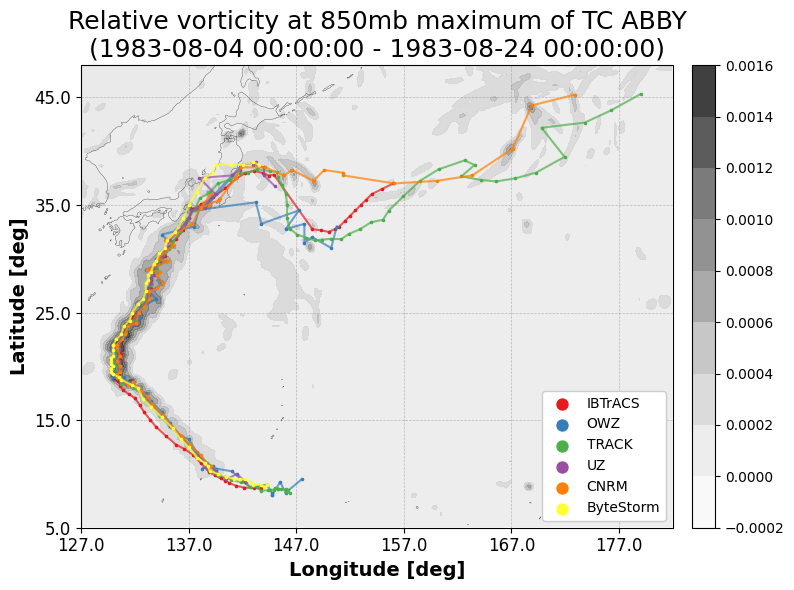

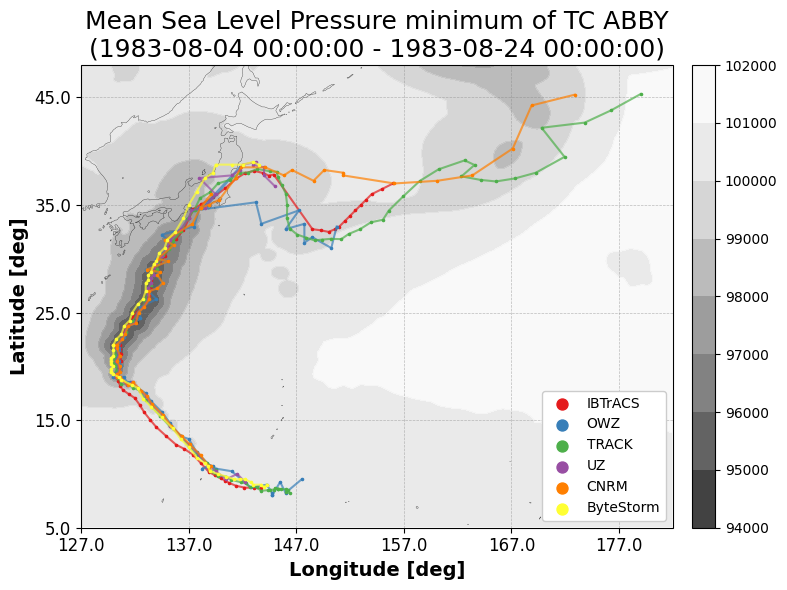

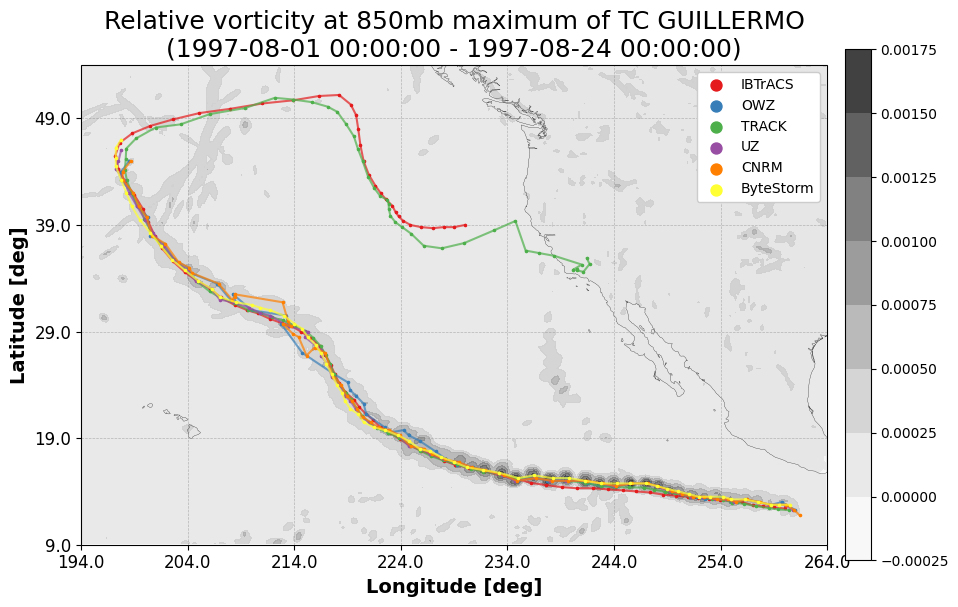

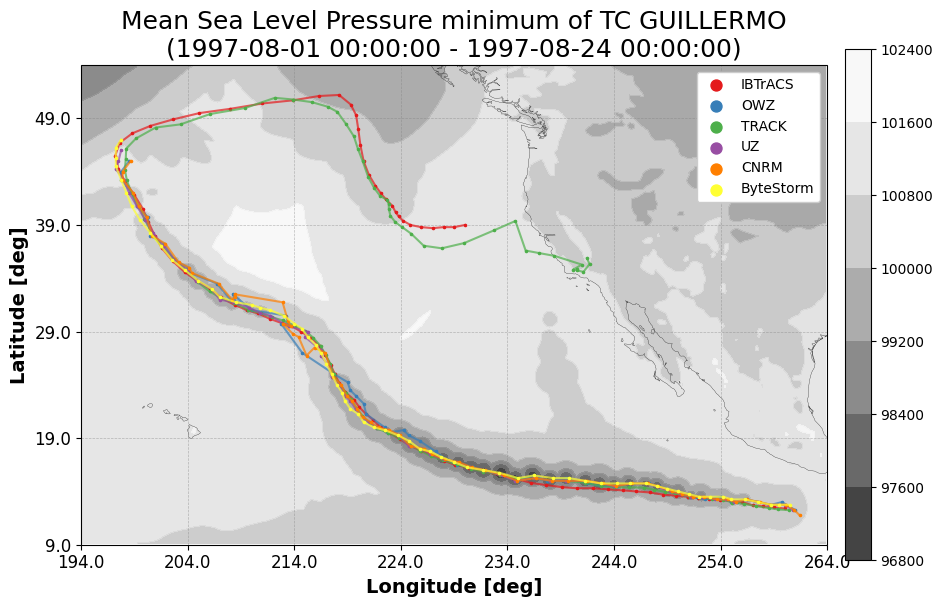

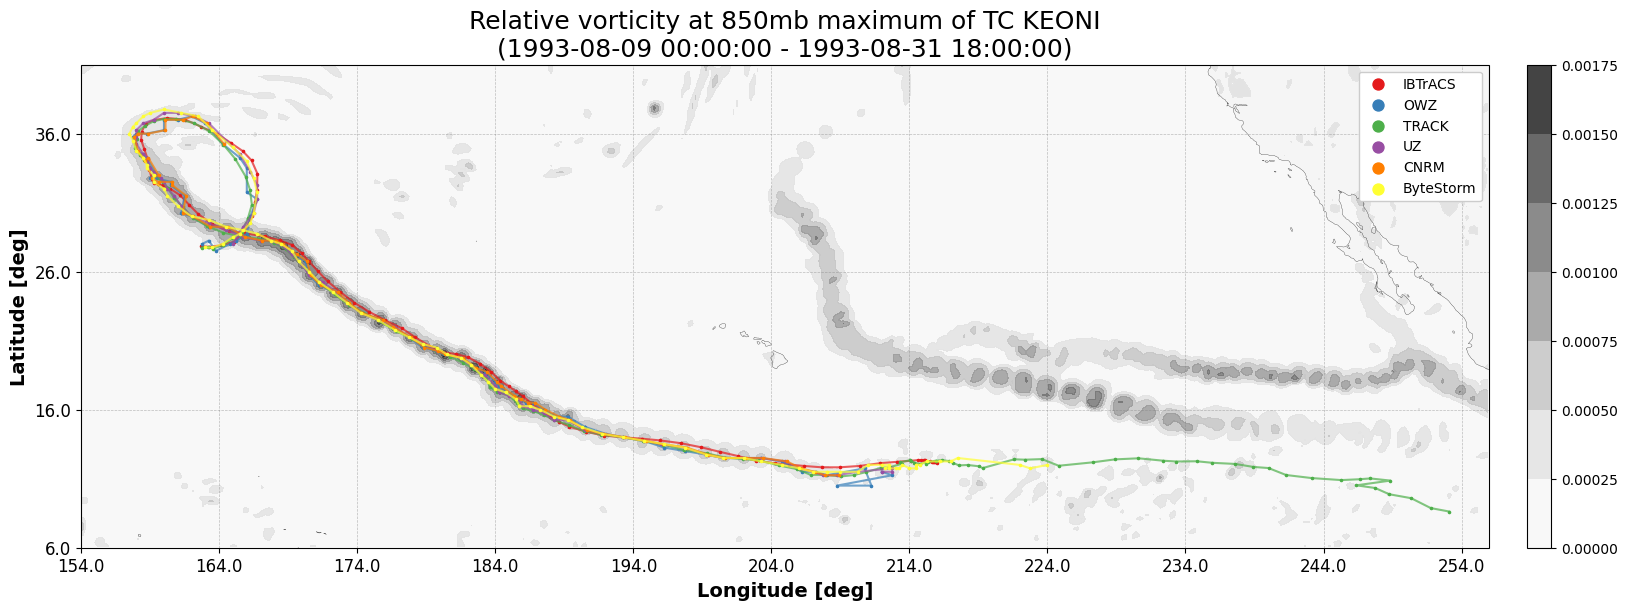

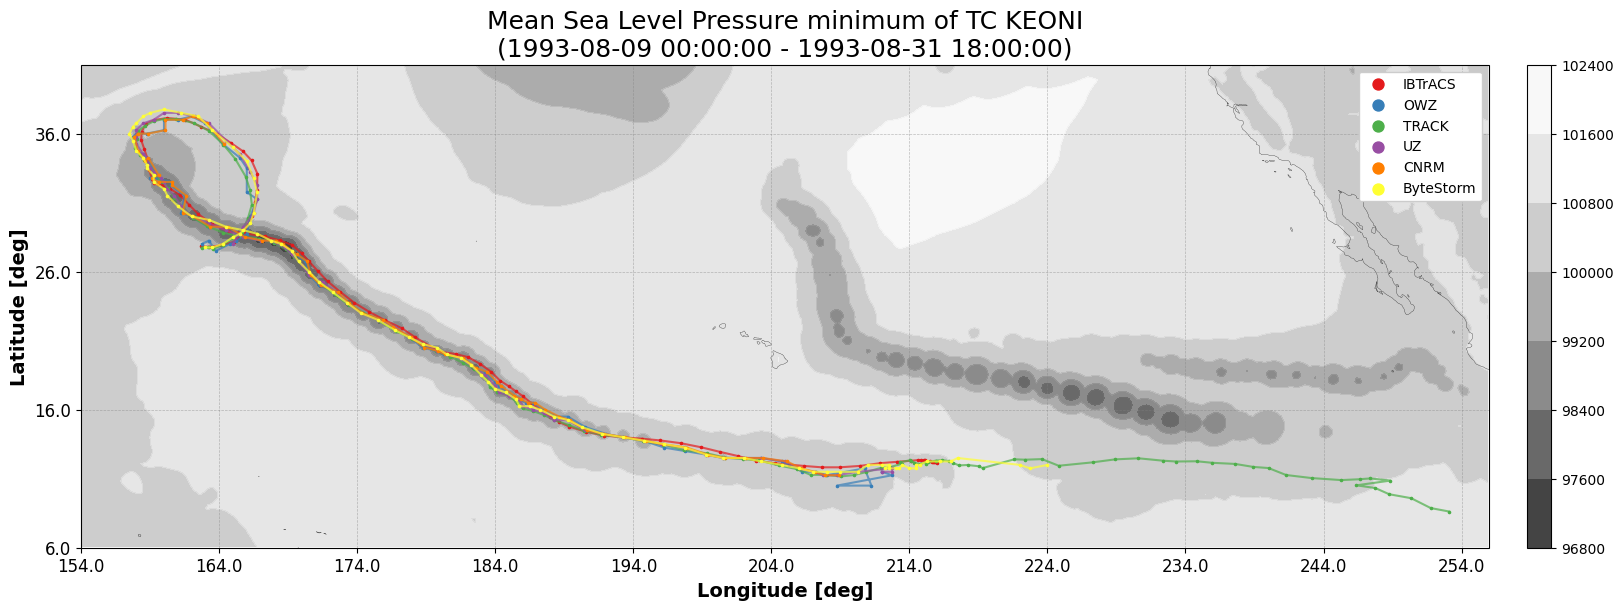

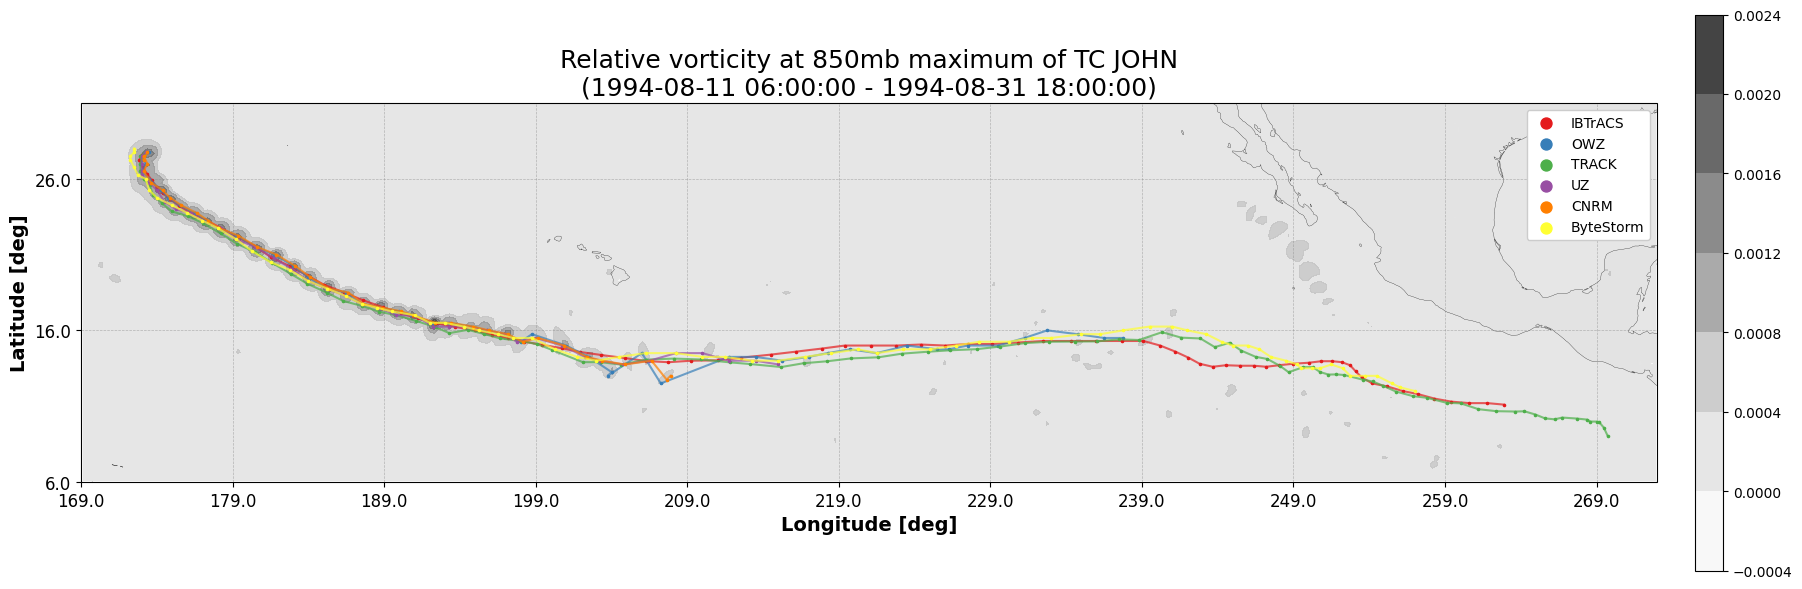

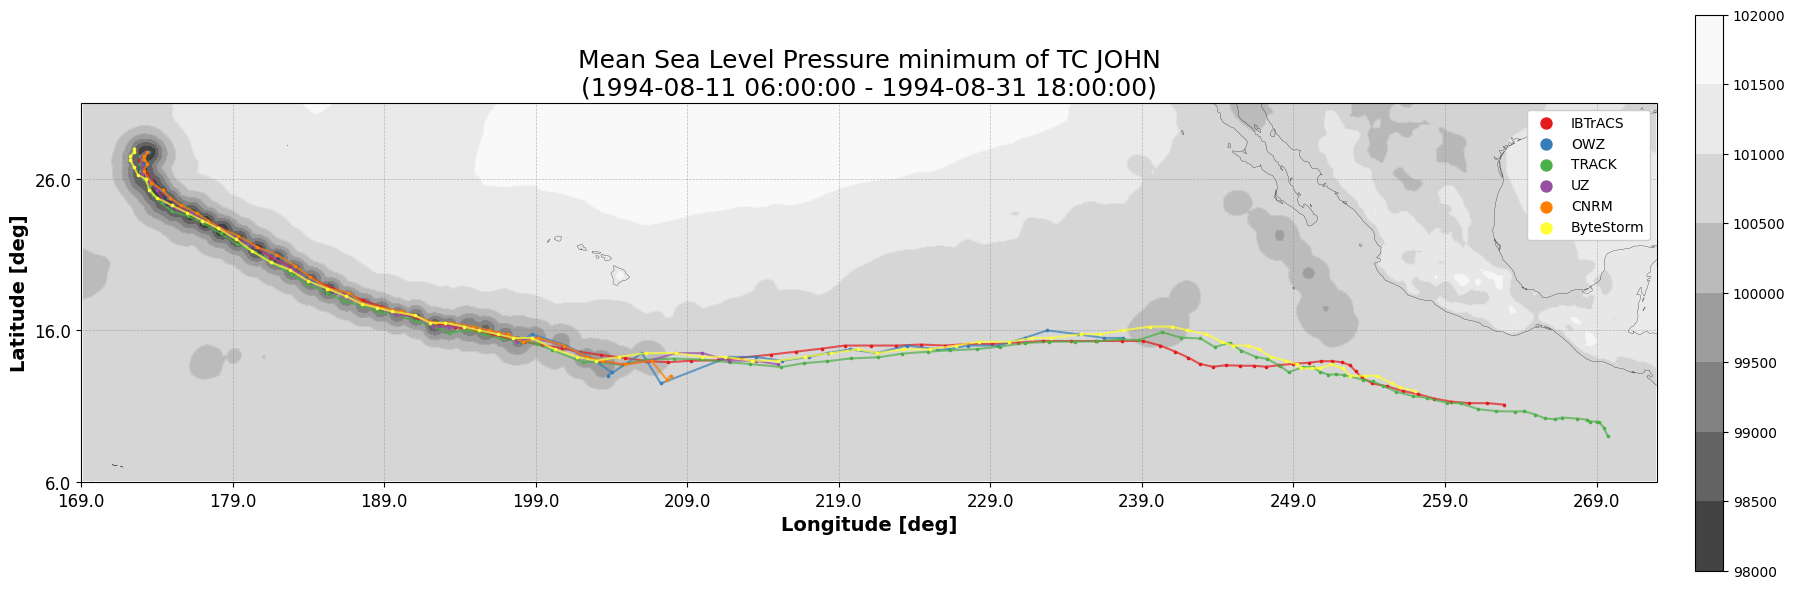

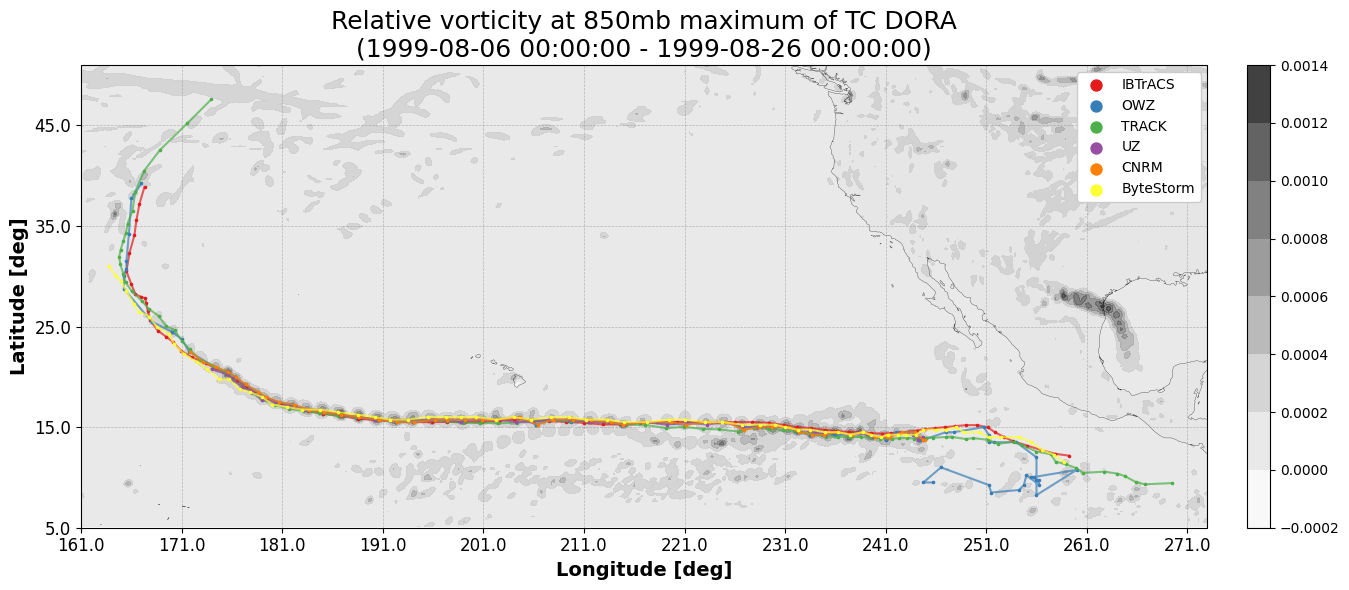

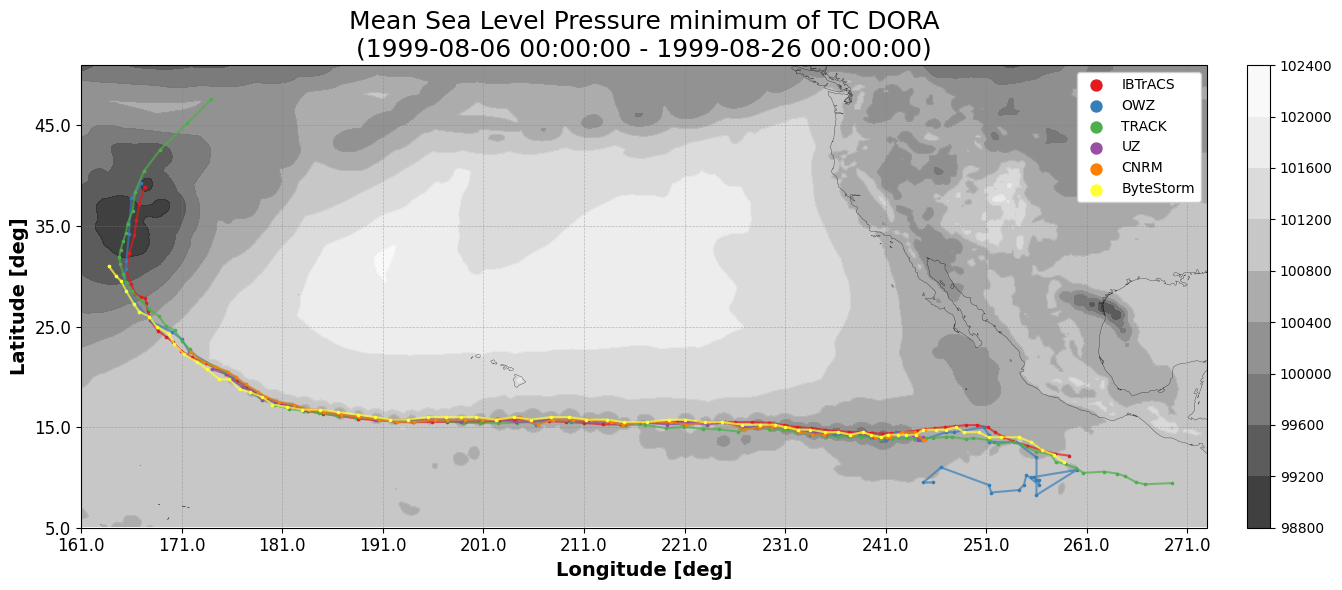

In [26]:
for selected_tc in ['ABBY', 'GUILLERMO', 'KEONI', 'JOHN', 'DORA']:
    selected_tc_track_id = track_id_and_name[track_id_and_name['name']==selected_tc]['track_id'].iloc[0]
    selected_tc_ibtracs = ibtracs_longest_tracks[ibtracs_longest_tracks['track_id'] == selected_tc_track_id]
    selected_tc_ibtracs['fname'] = selected_tc_ibtracs['time'].apply(find_filename)
    
    filenames = [os.path.join(dataset_src, fname) for fname in selected_tc_ibtracs['fname']]
    ds = xr.open_mfdataset(filenames)
    
    driver='vo_850'
    imtype='contourf'
    outfile = os.path.join(out_img_dir, f'{selected_tc}_{driver}_{imtype}.{file_ext}') if save_figures else None
    plot_tropical_cyclone_track_overlaid(
        ds, 
        owz, track, uz, cnrm, hybrid, 
        owz_matches_lts, track_matches_lts, uz_matches_lts, cnrm_matches_lts, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys', outfile=outfile, 
    )
    driver='msl'
    imtype='contourf'
    outfile = os.path.join(out_img_dir, f'{selected_tc}_{driver}_{imtype}.{file_ext}') if save_figures else None
    plot_tropical_cyclone_track_overlaid(
        ds, 
        owz, track, uz, cnrm, hybrid, 
        owz_matches_lts, track_matches_lts, uz_matches_lts, cnrm_matches_lts, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys_r', outfile=outfile, 
    )

In [27]:
def plot_tropical_cyclone_track_overlaid(
        ds, hybrid, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver, imtype='img', cmap='RdBu_r', overlay=True, outfile=None, 
):
    def get_tracks_by_ibtracs_track_id(tracks, matches, track_id, algo):
        track_match_id = matches[matches['id_ibtracs']==track_id][f'id_{algo}'].iloc[0]
        return tracks[tracks['track_id'] == track_match_id]

    def get_data(ds, variable, extent):
        lon_min, lon_max, lat_min, lat_max = extent
        if variable == 'msl':
            return ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).min('time', skipna=True)[variable].load().data
        elif variable == 'vo_850':
            return ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max)).max('time', skipna=True)[variable].load().data
        else:
            raise ValueError()

    if driver == 'vo_850':
        driver_title = 'Relative vorticity at 850mb maximum'
    elif driver == 'msl':
        driver_title = 'Mean Sea Level Pressure minimum'

    # colors = [
    #     'tab:blue', 
    #     'tab:orange', 
    #     'tab:green', 
    #     'tab:red', 
    #     'tab:purple', 
    #     'tab:cyan', 
    # ]
    # colors = plt.get_cmap('tab10').colors
    colors = plt.get_cmap('Set1').colors
    start_date, end_date = f'{selected_tc_ibtracs["time"].sort_values().iloc[0]}', f'{selected_tc_ibtracs["time"].sort_values().iloc[-1]}'

    # get the TC tracks for each tracker
    hybrid_tracks = get_tracks_by_ibtracs_track_id(hybrid, hybrid_matches_lts, selected_tc_track_id, our_work_name)

    # get the extent of the data
    lat_min = np.round(np.min((selected_tc_ibtracs['lat'].min(), hybrid_tracks['lat'].min())) - 3)
    lat_max = np.round(np.max((selected_tc_ibtracs['lat'].max(), hybrid_tracks['lat'].max())) + 3)
    lon_min = np.round(np.min((selected_tc_ibtracs['lon'].min(), hybrid_tracks['lon'].min())) - 3)
    lon_max = np.round(np.max((selected_tc_ibtracs['lon'].max(), hybrid_tracks['lon'].max())) + 3)
    
    offset = -lon_min-96 if selected_tc == 'GUILLERMO' else 0
    image_extent = [lon_min, lon_max, lat_min, lat_max]

    width = (lon_max - lon_min) / lon_max
    height = (lat_max - lat_min) / lat_max
    ratio = width / height
    if ratio >= 0.4:
        figsize = (20, 6)
        cbar_kwargs = {'orientation': 'vertical', 'pad': 0.02}
    else:
        figsize = (10, 6)
        cbar_kwargs = {'orientation': 'vertical', 'pad': 0.02}
    
    # set map extent
    central_longitude = (lon_max - lon_min)
    proj_central_longitude = 0 if selected_tc == 'GUILLERMO' else central_longitude

    fig = plt.figure(figsize=figsize)
    proj = ccrs.PlateCarree(central_longitude=proj_central_longitude)
    ax = plt.axes(projection=proj)

    ax.set_extent(image_extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='50m', lw=0.2)
    ax.add_feature(cf.LAND, facecolor='lightgrey', alpha=0.3)

    data = get_data(ds, driver, image_extent)

    fontdict = {'weight':'bold', 'size':14}
    # title_fontdict = {'size':18}
    ticksize = 12

    # plot tracks in each basin
    alpha = 0.5
    marker_size = 10.0
    transform = ccrs.PlateCarree()

    plt.title(f'{driver_title} of TC {selected_tc}\n({start_date} - {end_date})', fontsize = 18)
    
    ax.plot(selected_tc_ibtracs['lon'], selected_tc_ibtracs['lat'], alpha=0.7, transform=transform, color='tab:blue', zorder=999)
    ax.scatter(selected_tc_ibtracs['lon'], selected_tc_ibtracs['lat'], s=marker_size, marker='.', alpha=1.0, transform=transform, color='tab:blue', label='IBTrACS', zorder=999)

    ax.plot(hybrid_tracks['lon'], hybrid_tracks['lat'], alpha=0.7, transform=transform, color='tab:red', zorder=999)
    ax.scatter(hybrid_tracks['lon'], hybrid_tracks['lat'], s=marker_size, marker='.', alpha=1.0, transform=transform, color='tab:red', label=our_work_name, zorder=999)

    if overlay:
        if imtype == 'img':
            im = ax.imshow(data, cmap=cmap, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.8)
        elif imtype == 'contourf':
            im = ax.contourf(data, cmap=cmap, origin='upper', extent=image_extent, transform=ccrs.PlateCarree(), alpha=0.8)
    
    fig.colorbar(im, ax=ax, **cbar_kwargs)

    # x-axis
    longitudes = np.arange(lon_min, lon_max+1, 10)
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.xaxis.set_major_locator(mticker.FixedLocator(longitudes-central_longitude + offset))
    ax.set_xticklabels(longitudes, size=ticksize)
    ax.set_xticks(longitudes-central_longitude + offset)
    ax.set_xlabel('Longitude [deg]', fontdict=fontdict)

    # y-axis
    latitudes = np.arange(lat_min, lat_max+1, 10)
    lat_formatter = LatitudeFormatter()
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.yaxis.set_major_locator(mticker.FixedLocator(latitudes))
    ax.set_yticklabels(latitudes, size=ticksize)
    ax.set_yticks(latitudes)
    ax.set_ylabel('Latitude [deg]', fontdict=fontdict)

    # gridlines
    gl = ax.gridlines(crs=proj, draw_labels=False, dms=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(longitudes-central_longitude + offset)
    gl.ylocator = mticker.FixedLocator(latitudes)
    gl.xlines = True
    gl.ylines = True

    plt.legend(markerscale=5., framealpha=1)
    plt.tight_layout()
    if outfile is not None:
        plt.savefig(outfile, dpi=300)
    else:
        plt.show()

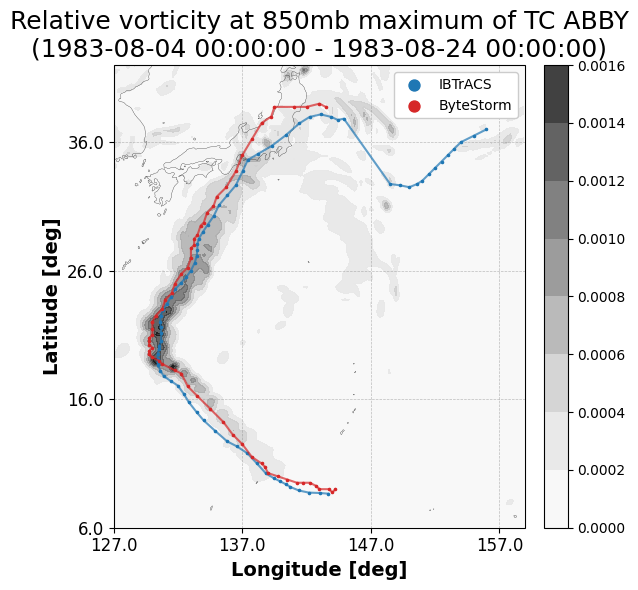

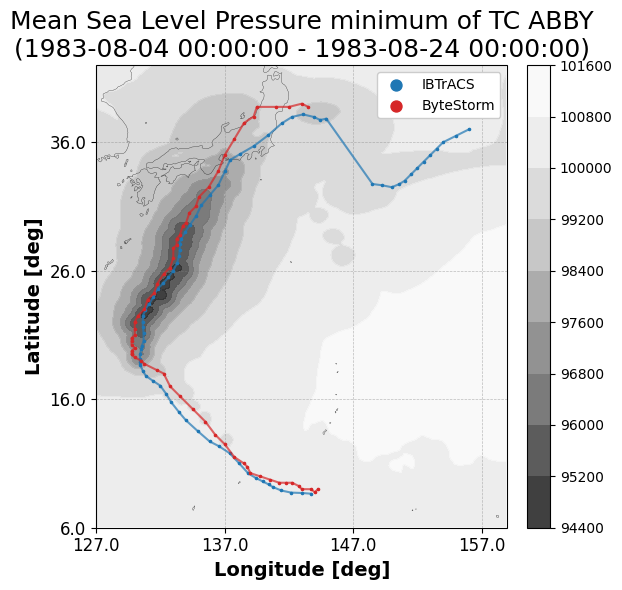

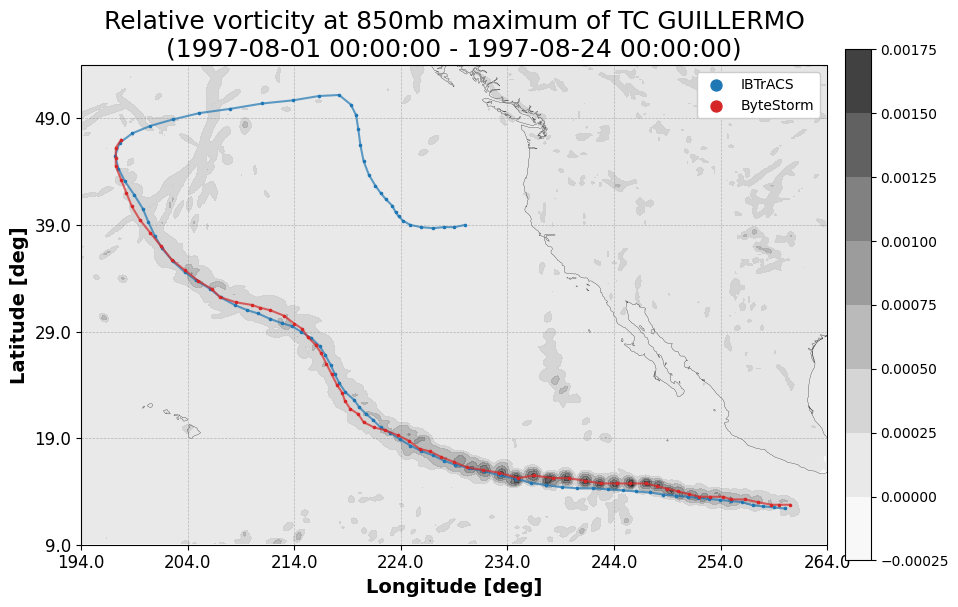

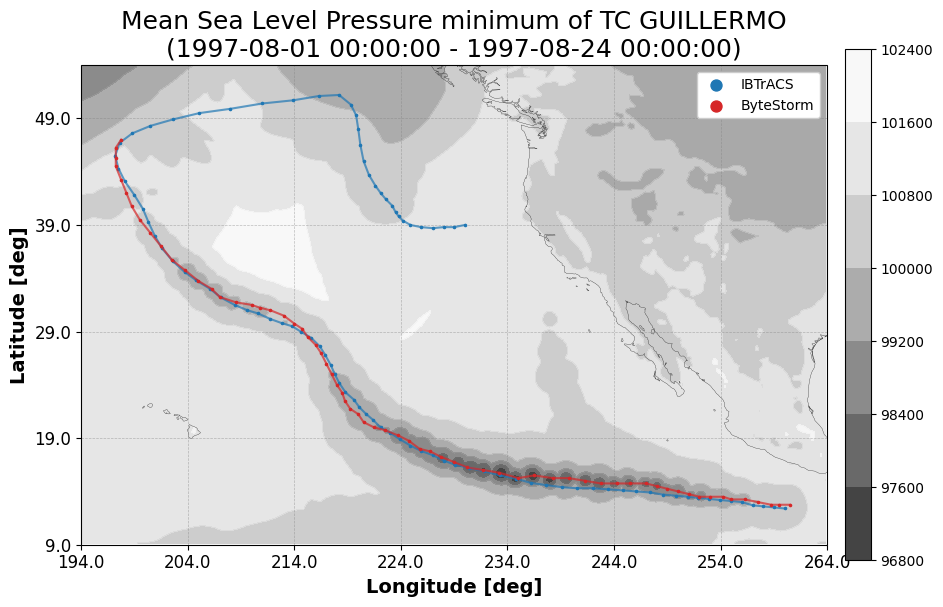

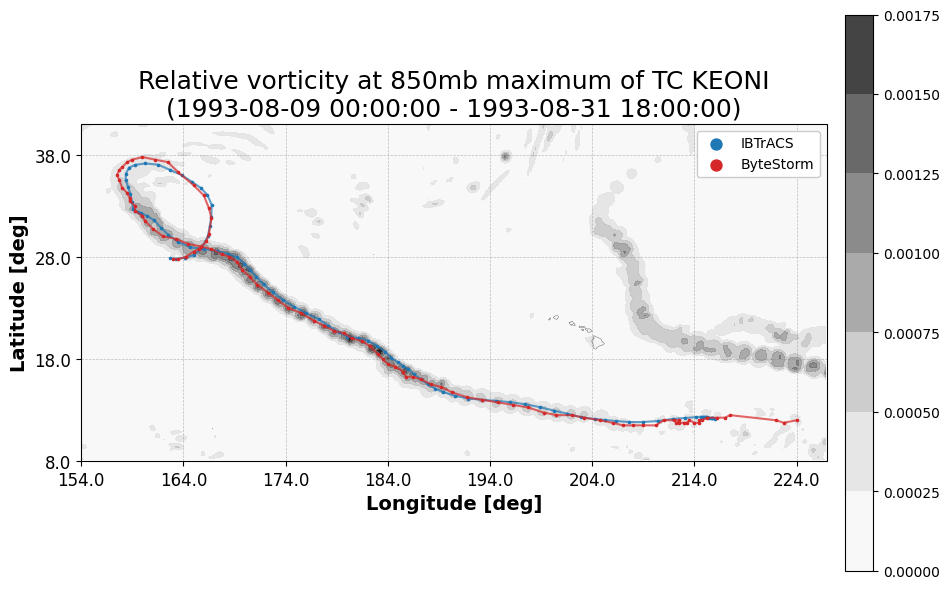

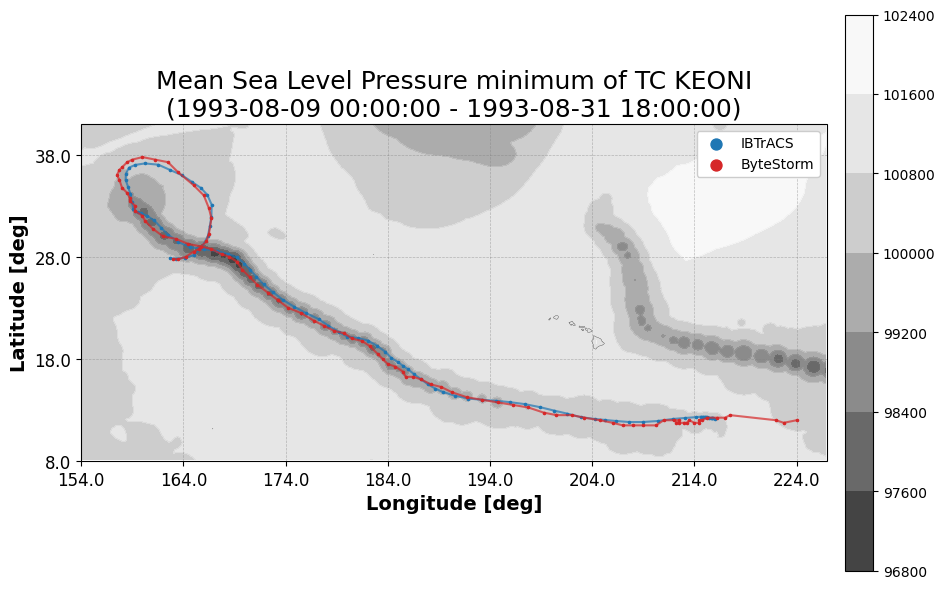

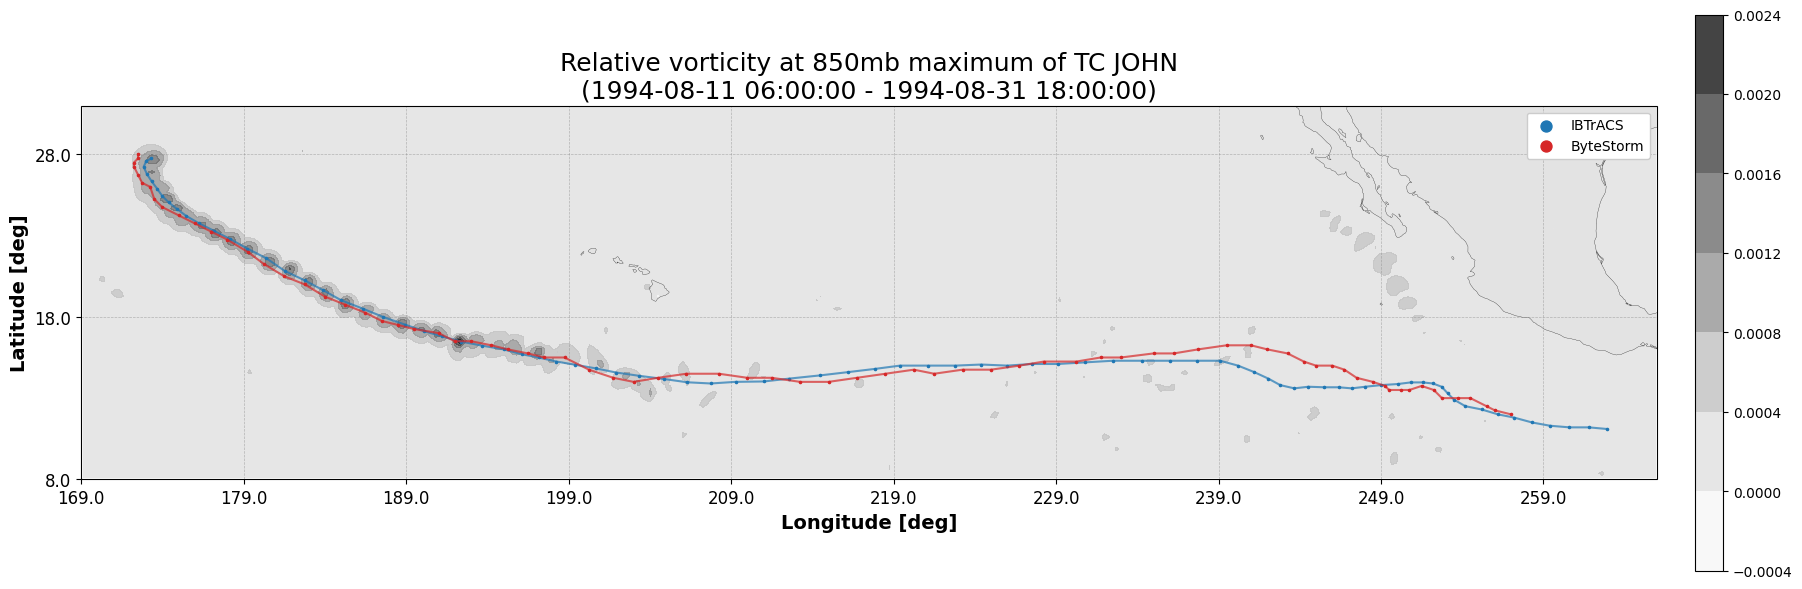

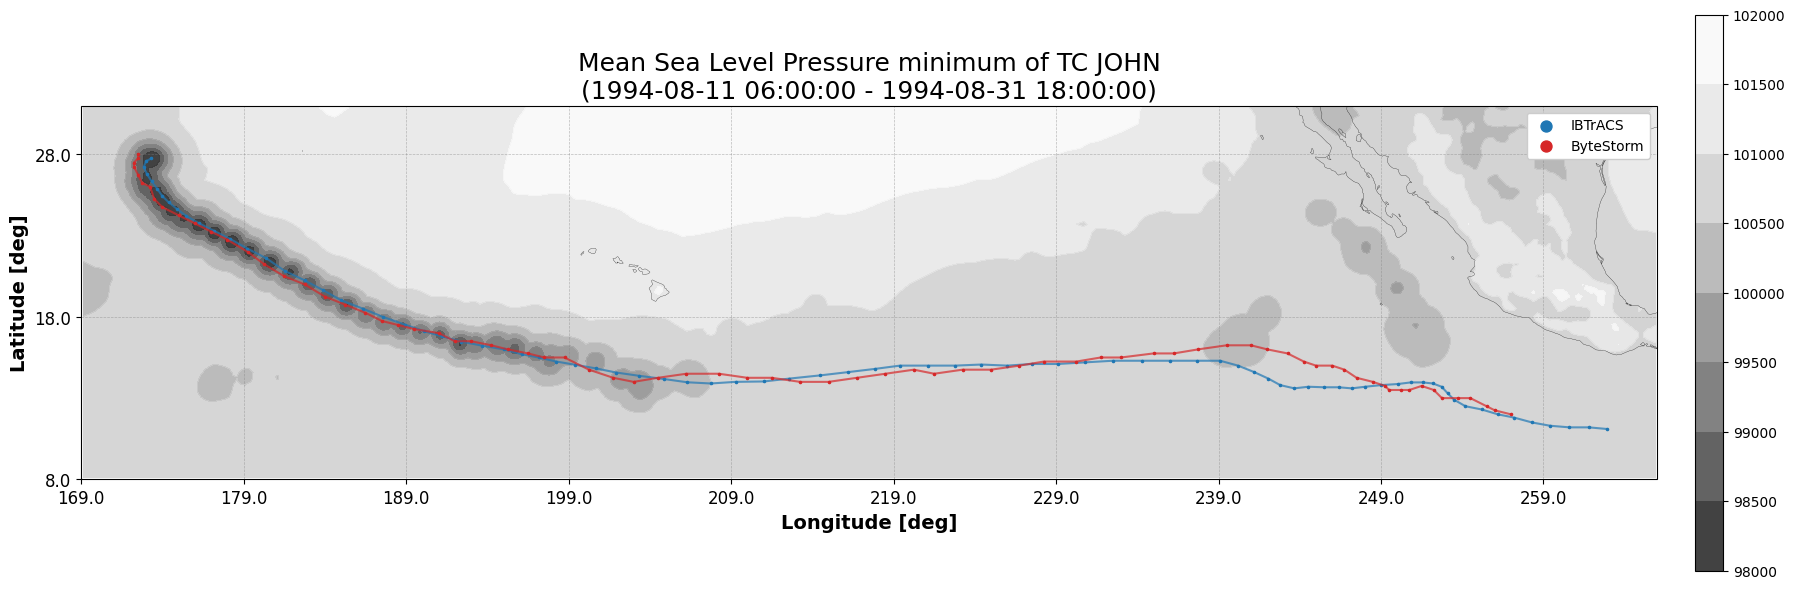

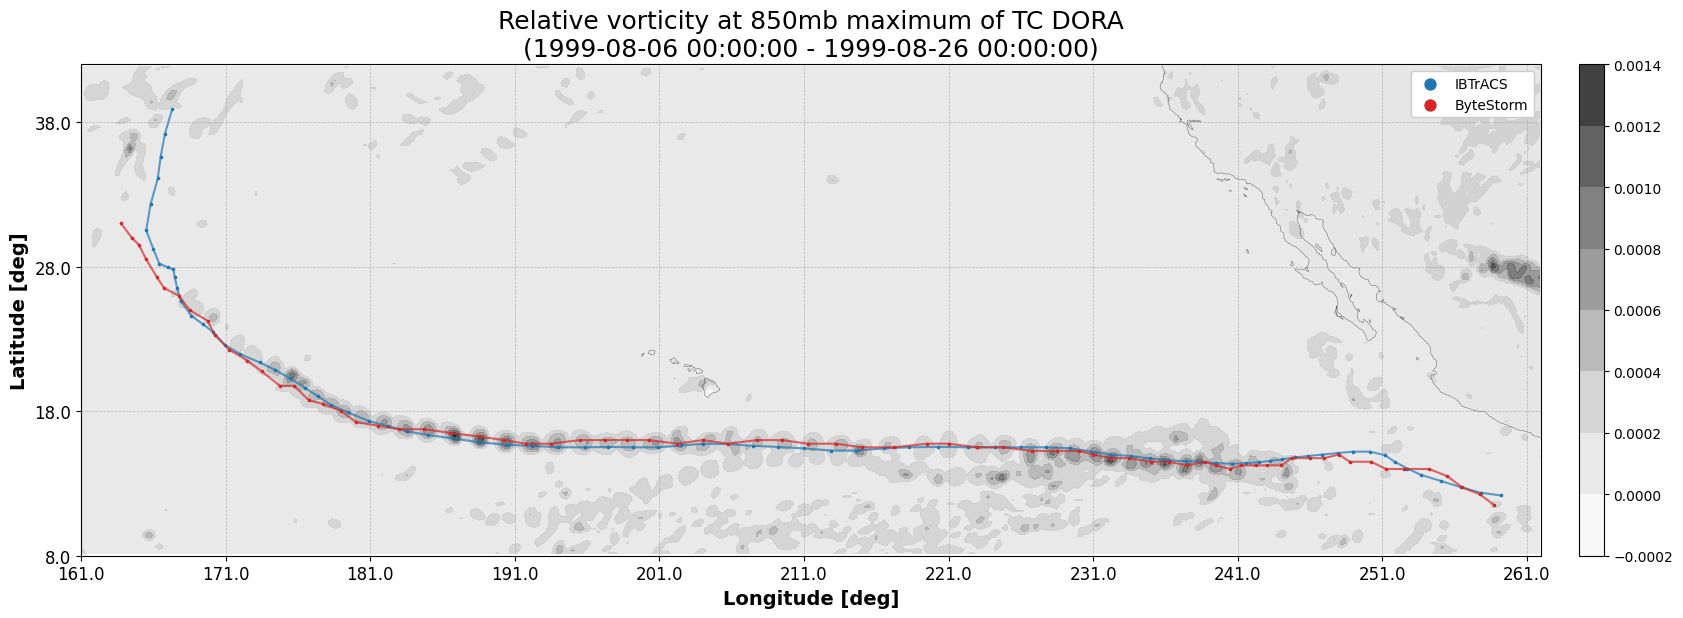

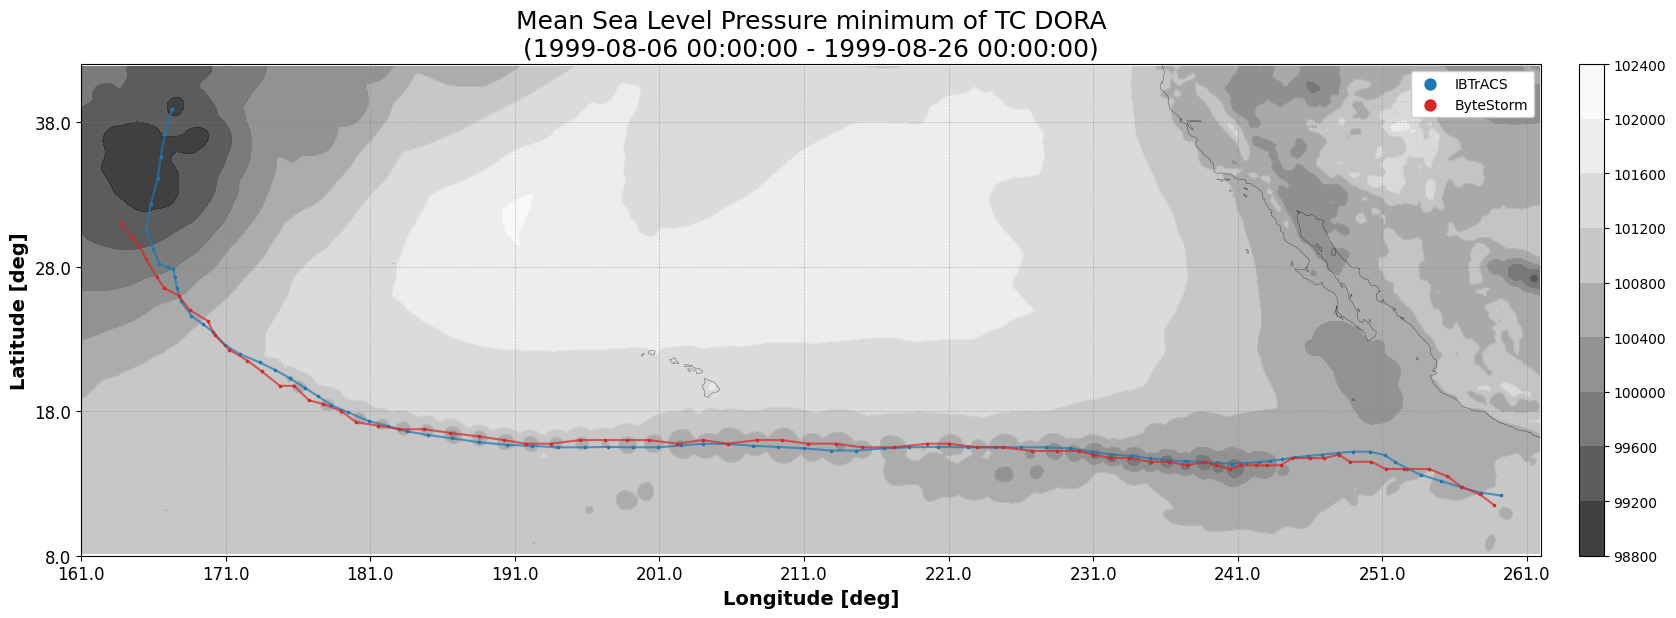

In [28]:
for selected_tc in ['ABBY', 'GUILLERMO', 'KEONI', 'JOHN', 'DORA']:
    selected_tc_track_id = track_id_and_name[track_id_and_name['name']==selected_tc]['track_id'].iloc[0]
    selected_tc_ibtracs = ibtracs_longest_tracks[ibtracs_longest_tracks['track_id'] == selected_tc_track_id]
    selected_tc_ibtracs['fname'] = selected_tc_ibtracs['time'].apply(find_filename)
    
    filenames = [os.path.join(dataset_src, fname) for fname in selected_tc_ibtracs['fname']]
    ds = xr.open_mfdataset(filenames)
    
    driver='vo_850'
    imtype='contourf'
    outfile = os.path.join(out_img_dir, f'{selected_tc}_{driver}_{imtype}_hybrid_only.{file_ext}') if save_figures else None
    plot_tropical_cyclone_track_overlaid(
        ds, hybrid, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys', outfile=outfile, 
    )
    driver='msl'
    imtype='contourf'
    outfile = os.path.join(out_img_dir, f'{selected_tc}_{driver}_{imtype}_hybrid_only.{file_ext}') if save_figures else None
    plot_tropical_cyclone_track_overlaid(
        ds, hybrid, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys_r', outfile=outfile, 
    )

In [30]:
# TODO: PER IL DELIVERABLE FINALE DI INTERTWIN
"""
for selected_tc in ['KEONI']:
    selected_tc_track_id = track_id_and_name[track_id_and_name['name']==selected_tc]['track_id'].iloc[0]
    selected_tc_ibtracs = ibtracs_longest_tracks[ibtracs_longest_tracks['track_id'] == selected_tc_track_id]
    selected_tc_ibtracs['fname'] = selected_tc_ibtracs['time'].apply(find_filename)
    
    filenames = [os.path.join(dataset_src, fname) for fname in selected_tc_ibtracs['fname']]
    ds = xr.open_mfdataset(filenames)
    
    driver='vo_850'
    imtype='contourf'
    outfile = os.path.join(out_img_dir, f'deliverable_{selected_tc}_{driver}_{imtype}_hybrid_only.{file_ext}') if save_figures else None
    plot_tropical_cyclone_track_overlaid(
        ds, hybrid, hybrid_matches_lts, 
        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys', overlay=False, outfile=outfile, 
    )
"""
    # driver='msl'
    # imtype='contourf'
    # outfile = os.path.join(out_img_dir, f'deliverable_{selected_tc}_{driver}_{imtype}_hybrid_only.{file_ext}') if save_figures else None
    # plot_tropical_cyclone_track_overlaid(
    #     ds, hybrid, hybrid_matches_lts, 
    #     selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys_r', overlay=False, outfile=outfile, 
    # )

"\nfor selected_tc in ['KEONI']:\n    selected_tc_track_id = track_id_and_name[track_id_and_name['name']==selected_tc]['track_id'].iloc[0]\n    selected_tc_ibtracs = ibtracs_longest_tracks[ibtracs_longest_tracks['track_id'] == selected_tc_track_id]\n    selected_tc_ibtracs['fname'] = selected_tc_ibtracs['time'].apply(find_filename)\n    \n    filenames = [os.path.join(dataset_src, fname) for fname in selected_tc_ibtracs['fname']]\n    ds = xr.open_mfdataset(filenames)\n    \n    driver='vo_850'\n    imtype='contourf'\n    outfile = os.path.join(out_img_dir, f'deliverable_{selected_tc}_{driver}_{imtype}_hybrid_only.{file_ext}') if save_figures else None\n    plot_tropical_cyclone_track_overlaid(\n        ds, hybrid, hybrid_matches_lts, \n        selected_tc, selected_tc_track_id, selected_tc_ibtracs, driver=driver, imtype=imtype, cmap='Greys', overlay=False, outfile=outfile, \n    )\n"

# Evaluating the Smoothness of a TC Track

In [31]:
import numpy as np
from geopy.distance import geodesic
from math import atan2, radians, degrees, sin, cos

def bearing(lat1, lon1, lat2, lon2):
    """Calcola il bearing (angolo in gradi) tra due coordinate geografiche"""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = sin(dlon) * cos(lat2)
    y = cos(lat1)*sin(lat2) - sin(lat1)*cos(lat2)*cos(dlon)
    brng = atan2(x, y)
    return (degrees(brng) + 360) % 360

def track_smoothness(latitudes, longitudes):
    bearings = []
    
    for i in range(1, len(latitudes)):
        brng = bearing(latitudes[i-1], longitudes[i-1], latitudes[i], longitudes[i])
        bearings.append(brng)

    # Calcolo variazione dell'angolo tra step successivi
    delta_bearings = [abs(bearings[i] - bearings[i-1]) for i in range(1, len(bearings))]

    # Normalizza angoli a [0, 180]
    delta_bearings = [min(d, 360 - d) for d in delta_bearings]

    # Misura di "non smoothness": deviazione standard o media
    smoothness_score = np.std(delta_bearings)  # più piccolo = più smooth
    return smoothness_score, delta_bearings

In [32]:
hybrid_matches

,id_ByteStorm,id_ibtracs,matching_timesteps,dist
0,OT_10572_(6293-6317),1987209N12259,12,76.501298
1,OT_10578_(6298-6342),1987213N11268,34,87.643438
2,OT_10588_(6311-6334),1987216N10270,20,104.960304
3,OT_10599_(6320-6367),1987219N08134,39,92.796664
4,OT_10636_(6339-6392),1987219N08155,52,95.518318
...,...,...,...,...
396,OT_9091_(5453-5465),1986214N09234,13,178.740146
397,OT_9095_(5455-5523),1986225N17134,57,71.922304
398,OT_9123_(5477-5518),1986228N19120,39,65.861723
399,OT_9148_(5497-5546),1986233N10263,38,127.840350


In [33]:
results = pd.DataFrame(
    columns = ['algo', 'score', 'delta_angles']
)

for track_id in ibtracs.track_id.unique():
    latlon = ibtracs[ibtracs['track_id']==track_id][['lat','lon']].to_numpy()
    lat, lon = latlon[:,0], latlon[:,1]
    score, delta_angles = track_smoothness(lat, lon)
    results = pd.concat([
        results, 
        pd.DataFrame({
            'algo': ['ibtracs'], 
            'track_id': [track_id], 
            'score': [score], 
            'delta_angles': [delta_angles], 
        })
    ])

for algo, matches, tracker, idname in zip(
        ['owz', 'track', 'uz', 'cnrm', 'hybrid'], 
        [owz_matches, track_matches, uz_matches, cnrm_matches, hybrid_matches], 
        [owz, track, uz, cnrm, hybrid], 
        ['id_owz', 'id_track', 'id_uz', 'id_cnrm', f'id_{our_work_name}']
    ):
    for track_id in matches[idname].unique():
    # for track_id in tracker.track_id.unique():
        latlon = tracker[tracker['track_id']==track_id][['lat','lon']].to_numpy()
        lat, lon = latlon[:,0], latlon[:,1]
        score, delta_angles = track_smoothness(lat, lon)
        results = pd.concat([
            results, 
            pd.DataFrame({
                'algo': [algo], 
                'track_id': [track_id], 
                'score': [score], 
                'delta_angles': [delta_angles], 
            })
        ])
results.reset_index()
results

,algo,score,delta_angles,track_id
0,ibtracs,25.754373,"[11.311580085000486, 1.3833159513274609, 1.056...",1980208N23153
0,ibtracs,6.456068,"[0.9218981879283206, 1.5824529553323146, 21.35...",1980213N11256
0,ibtracs,9.334286,"[5.720647927360858, 8.96934920269348, 5.190722...",1980219N15165
0,ibtracs,7.169179,"[21.387242673471064, 17.022033915116765, 0.678...",1980219N15258
0,ibtracs,12.098778,"[4.19344617788164, 5.469472897236528, 2.782860...",1980225N11145
...,...,...,...,...
0,hybrid,55.438565,"[161.9468377902634, 154.46776949763742, 109.16...",OT_9091_(5453-5465)
0,hybrid,41.706760,"[0.0, 0.0, 135.5435620678722, 134.480824259597...",OT_9095_(5455-5523)
0,hybrid,21.584039,"[0.0, 89.93529485559964, 0.0, 43.8879191122072...",OT_9123_(5477-5518)
0,hybrid,17.287177,"[26.752519603435303, 26.877702078067614, 26.80...",OT_9148_(5497-5546)


In [34]:
import seaborn as sns

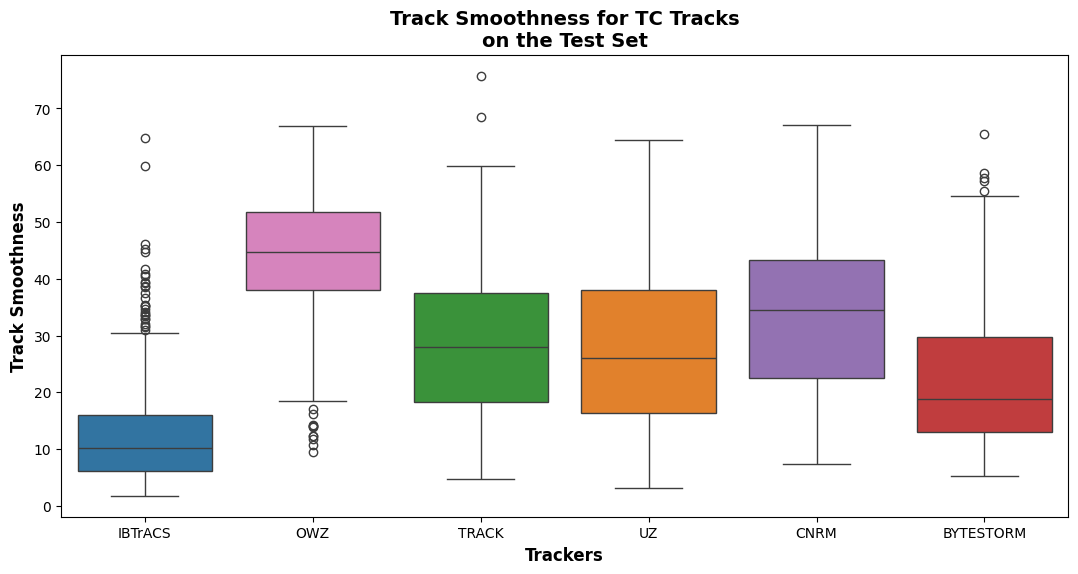

In [ ]:
# palette = sns.color_palette('tab10')
# palette = palette[0:5] + palette[-1:]
palette = [
    'tab:blue', 'tab:pink', 'tab:green', 'tab:orange', 'tab:purple', 'tab:red', 
]
fig, ax = plt.subplots(1,1, figsize=(13, 6))
ax = sns.boxplot(results, x='algo', y='score', palette=palette)
ax.set_xlabel("Trackers", fontdict={'size':12, 'weight': 'bold'})
ax.set_ylabel("Track Smoothness", fontdict={'size':12, 'weight': 'bold'})
ax.set_xticklabels(["IBTrACS", "OWZ", "TRACK", "UZ", "CNRM", our_work_name.upper()])
ax.set_title("Track Smoothness for TC Tracks\non the Test Set", fontdict={'size':14, 'weight': 'bold'})
outfile = os.path.join(out_img_dir, f'track_smoothness_for_test_set_hits.{file_ext}')
plt.savefig(outfile, dpi=300)
# plt.show()

In [ ]:
q_ibtracs_1st = np.quantile(results[results['algo']=='ibtracs']['score'].to_numpy(), q=0.25)
q_hybrid_1st = np.quantile(results[results['algo']=='hybrid']['score'].to_numpy(), q=0.25)

median_ibtracs = np.median(results[results['algo']=='ibtracs']['score'].to_numpy())
median_hybrid = np.median(results[results['algo']=='hybrid']['score'].to_numpy())

q_ibtracs_3rd = np.quantile(results[results['algo']=='ibtracs']['score'].to_numpy(), q=0.75)
q_hybrid_3rd = np.quantile(results[results['algo']=='hybrid']['score'].to_numpy(), q=0.75)

(q_ibtracs_1st, median_ibtracs, q_ibtracs_3rd), (q_hybrid_1st, median_hybrid, q_hybrid_3rd)

((6.048305887735523, 10.180340967797243, 16.044471724036804),
 (12.93072879424196, 18.767585615279042, 29.76232105145204))

In [ ]:
results

,algo,score,delta_angles,track_id
0,ibtracs,25.754373,"[11.311580085000486, 1.3833159513274609, 1.056...",1980208N23153
0,ibtracs,6.456068,"[0.9218981879283206, 1.5824529553323146, 21.35...",1980213N11256
0,ibtracs,9.334286,"[5.720647927360858, 8.96934920269348, 5.190722...",1980219N15165
0,ibtracs,7.169179,"[21.387242673471064, 17.022033915116765, 0.678...",1980219N15258
0,ibtracs,12.098778,"[4.19344617788164, 5.469472897236528, 2.782860...",1980225N11145
...,...,...,...,...
0,hybrid,55.438565,"[161.9468377902634, 154.46776949763742, 109.16...",OT_9091_(5453-5465)
0,hybrid,41.706760,"[0.0, 0.0, 135.5435620678722, 134.480824259597...",OT_9095_(5455-5523)
0,hybrid,21.584039,"[0.0, 89.93529485559964, 0.0, 43.8879191122072...",OT_9123_(5477-5518)
0,hybrid,17.287177,"[26.752519603435303, 26.877702078067614, 26.80...",OT_9148_(5497-5546)
